In [1]:
import numpy as np
import matplotlib.pyplot as plt


from snudd.geometry import SolarAngles

In [2]:
t0 = 91
T  = 182*2

GranSasso = SolarAngles(latitude=42.47, t0=t0, T=T)

In [3]:
angles, weights = GranSasso.zenith_hist(bins=25)
# print(angles, weights)

In [4]:
from snudd.nsi import earth_matter as em 
from snudd.nsi import oscillation as osc 
from snudd.models import GeneralNSI
import snudd.nsi.nsi_probabilities as probs

In [5]:
SM_matrix = np.array([[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]])

eta = 0
phi = 0

sm_model = GeneralNSI(SM_matrix, eta, phi)



Enuspace = np.geomspace(1e-6,2e1, 400)


xr_km = [0., 1221.5, 3480.0, 5701.0, 5771.0, 5971.0, 6151.0,
               6346.6, 6356.0, 6368.0, 6371.0, 6371.0 + 15.0]  # your boundaries
coeffs = [
    (13.0885, 0.0, -8.8381, 0.0),   # layer 1: a,b,c,d in r = R/RE
    (12.5815, -1.2638, -3.6426, -5.528),  # layer 2
    (7.9565,  -6.4761,  5.5283,  -3.0807),  # ...
    (5.3197,  -1.4836,  0.0,  0.0),
    (11.2494,  -8.0298,  0.0,  0.0),
    (7.1089,  -3.8045,  0.0,  0.0),
    (2.6910,   0.6924,  0.0,  0.0),
    (2.9,      0.0,  0.0,  0.0),
    (2.6,    0.0,  0.0,  0.0),
    (1.02,    0.0,  0.0,  0.0),
    (0.000,    0.0,  0.0,  0.0),
]
PREMmodel = em.LayeredPolyEarth(xr_km=xr_km, coeffs=coeffs,
                         Ye_core=0.466, Ye_mantle=0.494)
PREMprob = em.EarthProbEvolve(osc_params=osc.osc_params_best, model=sm_model, earthmodel=PREMmodel, Nst=50, Nav=50 )



density_sm = probs.DensityMatrixCalculator(sm_model).density(Enuspace, '8B')
density_mass_sm = probs.DensityMatrixCalculator(sm_model).density_mass(Enuspace, '8B')



## Check if density matrix is decohered

In [6]:
Upmns = osc.UPMNS(osc.osc_params_best)
print("\nPMNS matrix\n",Upmns)
print(Upmns.conj().T)
print(np.matmul(Upmns.conj().T, Upmns))

np.shape(density_sm)
print("\nDensity matrix\n", density_sm[0])
print(np.matmul(np.matmul(Upmns.conj().T, density_mass_sm[0]), Upmns))




density_mass = np.matmul(np.matmul(Upmns.conj().T, density_sm[0]), Upmns)
print("\nDensity matrix in mass basis\n",density_mass)
sum([density_mass[0,0], density_mass[1,1], density_mass[2,2]])


PMNS matrix
 [[ 0.82287807+0.j         -0.46504969-0.2905953j   0.14884502+0.j        ]
 [ 0.25731694-0.21386974j  0.65362181+0.02999832j  0.6781787 +0.j        ]
 [-0.41267515+0.20154064j -0.51975804+0.03183345j  0.71966576+0.j        ]]
[[ 0.82287807-0.j          0.25731694+0.21386974j -0.41267515-0.20154064j]
 [-0.46504969+0.2905953j   0.65362181-0.02999832j -0.51975804-0.03183345j]
 [ 0.14884502-0.j          0.6781787 -0.j          0.71966576-0.j        ]]
[[ 1.00000000e+00+2.70379279e-18j -2.81882750e-17-3.86496386e-17j
   2.50525990e-17-5.00912491e-18j]
 [-2.81882750e-17+4.53097088e-17j  1.00000000e+00+6.94198305e-18j
   5.14578129e-17+4.74479319e-18j]
 [ 2.50525990e-17+5.00912491e-18j  5.14578129e-17-4.74479319e-18j
   1.00000000e+00+0.00000000e+00j]]

Density matrix
 [[ 0.5493961 -3.15223300e-18j  0.05154334+6.62178815e-02j
  -0.15761877-6.24005748e-02j]
 [ 0.05154334-6.62178815e-02j  0.21476257+3.34999118e-18j
  -0.19216481+1.36955275e-02j]
 [-0.15761877+6.24005748e-02j -0.19

np.complex128(1.0000000000000002+2.0412509105727648e-17j)

## Evolve density matrix through earth

In [7]:
rho_earthceta1 = PREMprob.evolve_rhosolar(density_sm, Enuspace, ceta=0.025)

rho_earthceta2 = PREMprob.evolve_rhosolar(density_sm, Enuspace, ceta=0.5)

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

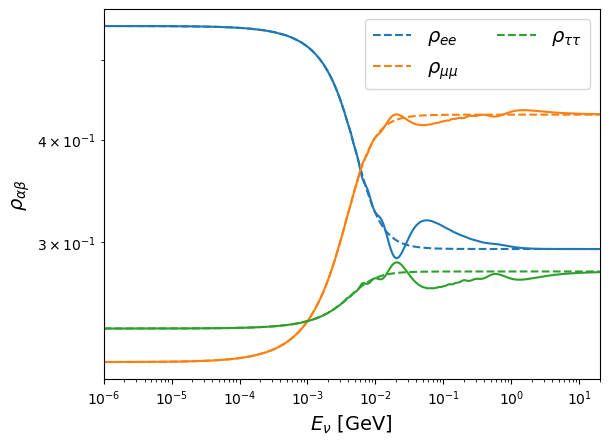

In [8]:
plt.loglog(Enuspace,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )
plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\tau\tau}$',
           color="tab:green", ls='--' )

# plt.loglog(Enuspace,abs(density_mass_sm[:, 0,0]),  label=r'$\rho_{ee}$', 
#             color="tab:blue", ls='--' )
# plt.loglog(Enuspace,abs(density_mass_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
#            color="tab:orange", ls='--' )
# plt.loglog(Enuspace,abs(density_mass_sm[:, 2,2]),  label=r'$\rho_{\tau\tau}$',
#            color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_earthceta1[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_earthceta1[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_earthceta1[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

#plt.loglog(Enuspace, Pee*, label=r'$P_{ee}$', ls=':', color="tab:blue" )


plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

In [9]:
np.shape(rho_earthceta1)

(400, 3, 3)

In [10]:
import tqdm as tqdm

In [11]:
weights.sum()

np.float64(1.0001401477372538)

In [12]:
def rho_weighted_average(probevolution, rhosm, Enuspace, weights, angles):


    rho_ave = np.zeros(np.shape(rhosm), dtype=complex)
    
    for i in tqdm.tqdm(range(len(weights))):
        ceta = np.cos(angles[i])
        # evolve through earth
        rho_earth = probevolution.evolve_rhosolar(rhosm, Enuspace, ceta=ceta)
        rho_ave += weights[i] * rho_earth

    return rho_ave
        

In [13]:
rho_ave = rho_weighted_average(PREMprob, density_sm, Enuspace, weights, angles)

100%|██████████| 50/50 [02:47<00:00,  3.34s/it]


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

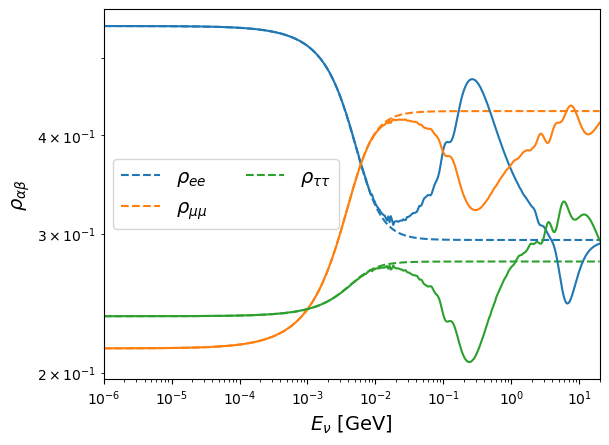

In [19]:
plt.loglog(Enuspace,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\tau\tau}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_ave[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_ave[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_ave[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

#plt.loglog(Enuspace, Pee*, label=r'$P_{ee}$', ls=':', color="tab:blue" )


plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

## Run with old oscillation parameters

In [15]:
params_old = osc.osc_params_old

rho_sun2 = probs.DensityMatrixCalculator(sm_model, osc_params=params_old).density(Enuspace, '8B')
PREMprob2 = em.EarthProbEvolve(osc_params=params_old, model=sm_model, earthmodel=PREMmodel)



In [16]:
rho_ave2 = rho_weighted_average(PREMprob2, rho_sun2, Enuspace, weights, angles)

100%|██████████| 50/50 [02:36<00:00,  3.12s/it]


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

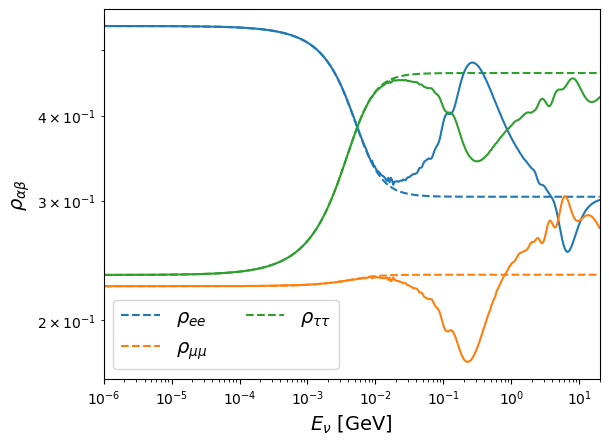

In [18]:
plt.loglog(Enuspace,abs(rho_sun2[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(rho_sun2[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(rho_sun2[:, 2,2]),  label=r'$\rho_{\tau\tau}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_ave2[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_ave2[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_ave2[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

#plt.loglog(Enuspace, Pee*, label=r'$P_{ee}$', ls=':', color="tab:blue" )


plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

In [22]:
angles < np.pi/2

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])